11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 31s 3us/step


C:\Users\Mercy\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9410 - loss: 0.1974 - val_accuracy: 0.9793 - val_loss: 0.0702
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9821 - loss: 0.0571 - val_accuracy: 0.9865 - val_loss: 0.0510
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9873 - loss: 0.0392 - val_accuracy: 0.9882 - val_loss: 0.0435
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9898 - loss: 0.0312 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9907 - val_loss: 0.0318
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9912 - loss: 0.0319
Test Accuracy: 99.12%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


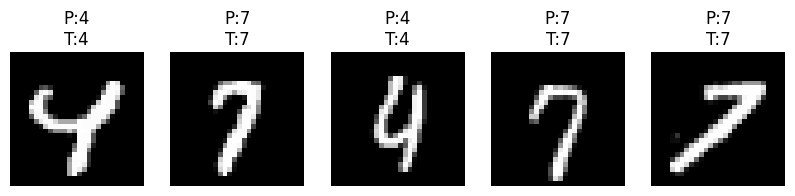

In [1]:


import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize and reshape for CNN
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Predict on 5 random test images
sample_idx = np.random.choice(len(x_test),5,replace=False)
sample_imgs = x_test[sample_idx]
sample_labels = y_test[sample_idx]
preds = model.predict(sample_imgs)

# Show predictions
plt.figure(figsize=(10,2))
for i, img in enumerate(sample_imgs):
    plt.subplot(1,5,i+1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(f"P:{np.argmax(preds[i])}\nT:{sample_labels[i]}")
    plt.axis('off')
plt.show()


In [2]:
import os
os.getcwd()


'D:\\'